<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/Dataset_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AP1.xlsx to AP1.xlsx
Saving AP2.xlsx to AP2.xlsx
Saving Qs_fast.xlsx to Qs_fast.xlsx
Saving SH1.xlsx to SH1.xlsx
Saving SH2.xlsx to SH2.xlsx
Saving XS1.xlsx to XS1.xlsx
Saving XS2.xlsx to XS2.xlsx


In [ ]:
!pip install pandas numpy matplotlib scikit-learn openpyxl


📂 Available files: ['.config', 'AP2.xlsx', 'SH2.xlsx', 'SH1.xlsx', 'AP1.xlsx', 'Qs_fast.xlsx', 'XS1.xlsx', 'XS2.xlsx', 'sample_data']


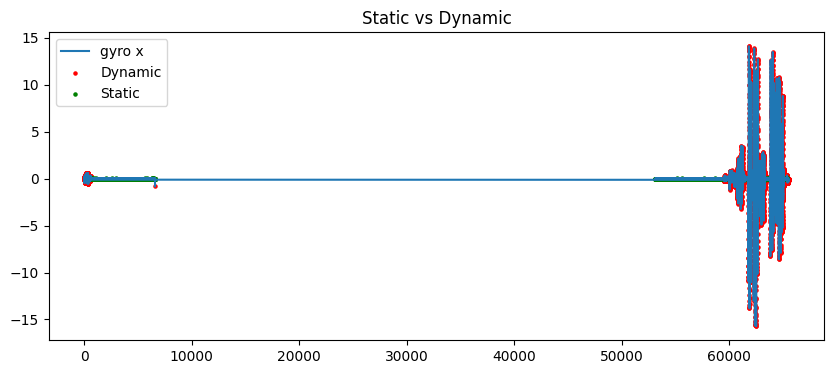


Feature shape: (18994, 9)

📊 Data Distribution:
Static: 13117
Dynamic: 5877

✅ Split Done
Train: 15194
Test: 3800

🚀 FINAL OUTPUT
Train sequences: (15144, 50, 9)
Test sequences: (3750, 50, 9)


In [6]:
%matplotlib inline

# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# 2. LOAD DATA
# =========================
def load_data(file_paths, quat_path):
    data = {}

    print("📂 Available files:", os.listdir())

    for name, path in file_paths.items():
        if path not in os.listdir():
            raise FileNotFoundError(f"{path} not found")
        data[name] = pd.read_excel(path)

    if quat_path not in os.listdir():
        raise FileNotFoundError(f"{quat_path} not found")

    quat = pd.read_excel(quat_path)

    return data, quat

# =========================
# 3. PREPROCESS
# =========================
def preprocess(data):
    columns = ["time", "ax", "ay", "az", "gx", "gy", "gz",
               "mx", "my", "mz", "ox", "oy", "oz", "ow"]

    for name in data:
        data[name].columns = columns

    return data

# =========================
# 4. LABEL STATIC / DYNAMIC
# =========================
def label_motion(df, threshold=0.1):
    gyro_mag = np.sqrt(df["gx"]**2 + df["gy"]**2 + df["gz"]**2)
    df["motion"] = (gyro_mag > threshold).astype(int)
    return df

# =========================
# 5. MERGE ALL DATA
# =========================
def merge_data(data):
    return pd.concat(data.values(), ignore_index=True)

# =========================
# 6. PREPARE FEATURES
# =========================
def prepare_features(combined, quat):
    quat.columns = ["qw","qx","qy","qz"]

    min_len = min(len(combined), len(quat))

    combined = combined.iloc[:min_len]
    quat = quat.iloc[:min_len]

    final = pd.concat([combined, quat], axis=1)

    X = final[["ax","ay","az","gx","gy","gz","mx","my","mz"]]
    y = final[["qw","qx","qy","qz"]]
    motion = final["motion"]

    return X, y, motion

# =========================
# FIXED BALANCED SPLIT
# =========================

from sklearn.model_selection import train_test_split

def balanced_motion_split(X, y, motion):

    # Reset index
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    motion = motion.reset_index(drop=True)

    # Split static/dynamic
    static_idx = motion == 0
    dynamic_idx = motion == 1

    X_static = X[static_idx]
    y_static = y[static_idx]

    X_dynamic = X[dynamic_idx]
    y_dynamic = y[dynamic_idx]

    print("\n📊 Data Distribution:")
    print("Static:", len(X_static))
    print("Dynamic:", len(X_dynamic))

    # Split separately
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
        X_static, y_static, test_size=0.2, random_state=42
    )

    Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
        X_dynamic, y_dynamic, test_size=0.2, random_state=42
    )

    # Combine properly
    X_train = pd.concat([Xs_tr, Xd_tr], axis=0)
    y_train = pd.concat([ys_tr, yd_tr], axis=0)

    X_test = pd.concat([Xs_te, Xd_te], axis=0)
    y_test = pd.concat([ys_te, yd_te], axis=0)

    # 🔥 KEY FIX: shuffle using SAME permutation
    train_idx = np.random.permutation(len(X_train))
    test_idx = np.random.permutation(len(X_test))

    X_train = X_train.iloc[train_idx].reset_index(drop=True)
    y_train = y_train.iloc[train_idx].reset_index(drop=True)

    X_test = X_test.iloc[test_idx].reset_index(drop=True)
    y_test = y_test.iloc[test_idx].reset_index(drop=True)

    print("\n✅ Split Done")
    print("Train:", len(X_train))
    print("Test:", len(X_test))

    return X_train, X_test, y_train, y_test

# =========================
# 8. NORMALIZATION
# =========================
def normalize(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

# =========================
# 9. SEQUENCE CREATION
# =========================
def create_sequences(X, y, window=50):
    X_seq, y_seq = [], []

    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])

    return np.array(X_seq), np.array(y_seq)

# =========================
# 10. VISUALIZE MOTION
# =========================
def plot_motion(df):
    plt.figure(figsize=(10,4))
    plt.plot(df["time"], df["gx"], label="gyro x")

    dynamic = df[df["motion"] == 1]
    static = df[df["motion"] == 0]

    plt.scatter(dynamic["time"], dynamic["gx"], color='red', s=5, label="Dynamic")
    plt.scatter(static["time"], static["gx"], color='green', s=5, label="Static")

    plt.legend()
    plt.title("Static vs Dynamic")
    plt.show()

# =========================
# MAIN
# =========================
def main():

    files = {
        "XS1": "XS1.xlsx",
        "XS2": "XS2.xlsx",
        "AP1": "AP1.xlsx",
        "AP2": "AP2.xlsx",
        "SH1": "SH1.xlsx",
        "SH2": "SH2.xlsx"
    }

    quat_file = "Qs_fast.xlsx"

    # Load
    data, quat = load_data(files, quat_file)

    # Preprocess
    data = preprocess(data)

    # Label motion
    for name in data:
        data[name] = label_motion(data[name])

    # Visualize ONE sensor
    plot_motion(data["XS1"])

    # Merge
    combined = merge_data(data)

    # Prepare dataset
    X, y, motion = prepare_features(combined, quat)

    print("\nFeature shape:", X.shape)

    # Balanced split
    X_train, X_test, y_train, y_test = balanced_motion_split(X, y, motion)

    # Normalize
    X_train, X_test = normalize(X_train, X_test)

    # Sequence creation
    X_train_seq, y_train_seq = create_sequences(X_train, y_train.values)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test.values)

    print("\n🚀 FINAL OUTPUT")
    print("Train sequences:", X_train_seq.shape)
    print("Test sequences:", X_test_seq.shape)


# =========================
# RUN
# =========================
if __name__ == "__main__":
    main()

Epoch 1: 0.018231
Epoch 2: 0.003401
Epoch 3: 0.001798
Epoch 4: 0.001644
Epoch 5: 0.001596
Epoch 6: 0.001602
Epoch 7: 0.000837
Epoch 8: 0.000558
Epoch 9: 0.001003
Epoch 10: 0.000638
Epoch 11: 0.000646
Epoch 12: 0.000445
Epoch 13: 0.001093
Epoch 14: 0.000885
Epoch 15: 0.000473
Epoch 16: 0.000465
Epoch 17: 0.000406
Epoch 18: 0.002077
Epoch 19: 0.000877
Epoch 20: 0.001028
Epoch 21: 0.000772
Epoch 22: 0.000495
Epoch 23: 0.001275
Epoch 24: 0.000753
Epoch 25: 0.000328
Epoch 26: 0.000173
Epoch 27: 0.000142
Epoch 28: 0.000121
Epoch 29: 0.000808
Epoch 30: 0.000283

📊 RMSE per component: [0.01421353 0.01130097 0.02465889 0.01327633]
📊 Overall RMSE: 0.01586243


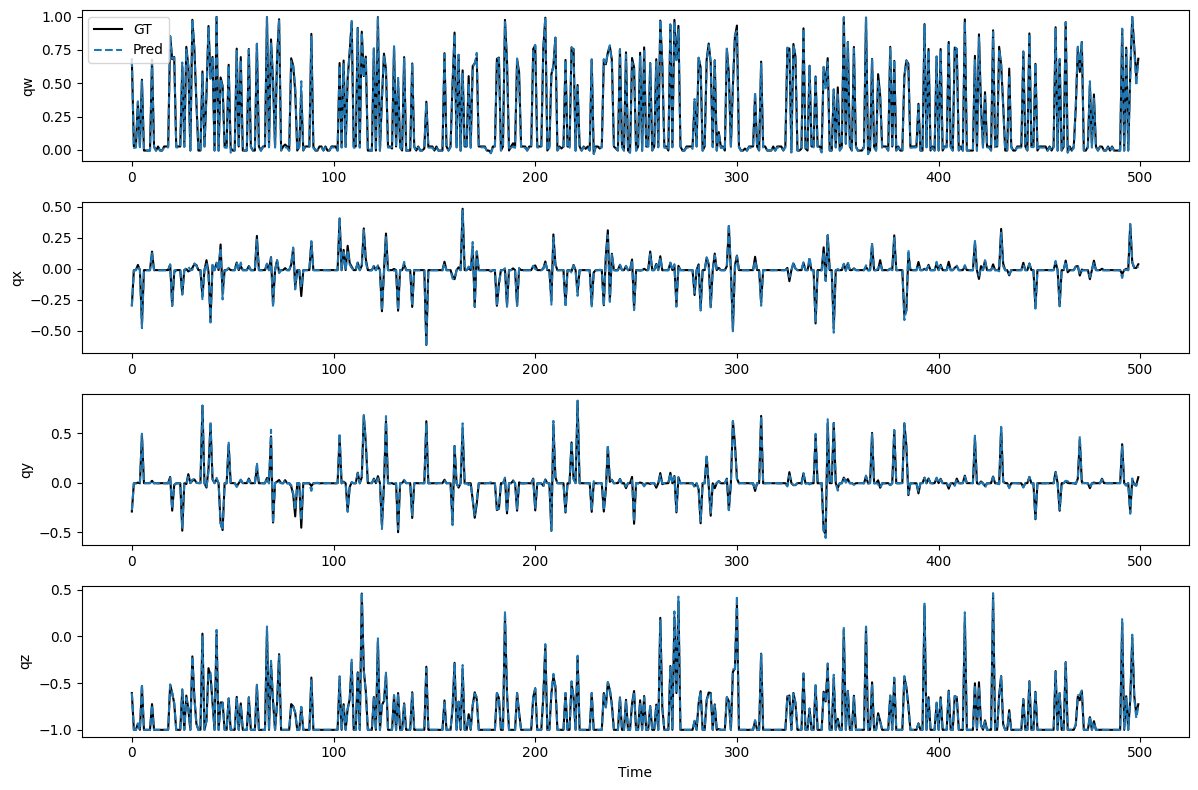

In [9]:

# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# 2. LOAD + PREPROCESS
# =========================
def load_data():
    files = ["XS1.xlsx","XS2.xlsx","AP1.xlsx","AP2.xlsx","SH1.xlsx","SH2.xlsx"]
    columns = ["time","ax","ay","az","gx","gy","gz","mx","my","mz","ox","oy","oz","ow"]

    dfs = []
    for f in files:
        df = pd.read_excel(f)
        df.columns = columns

        gyro_mag = np.sqrt(df["gx"]**2 + df["gy"]**2 + df["gz"]**2)
        df["motion"] = (gyro_mag > 0.1).astype(int)

        dfs.append(df)

    combined = pd.concat(dfs, ignore_index=True)

    quat = pd.read_excel("Qs_fast.xlsx")
    quat.columns = ["qw","qx","qy","qz"]

    min_len = min(len(combined), len(quat))
    combined = combined.iloc[:min_len]
    quat = quat.iloc[:min_len]

    final = pd.concat([combined, quat], axis=1)

    X = final[["ax","ay","az","gx","gy","gz"]].values
    y = final[["qw","qx","qy","qz"]].values
    motion = final["motion"].values

    return X, y, motion

# =========================
# 3. NORMALIZATION
# =========================
def normalize(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)

# =========================
# 4. CREATE SEQUENCES FIRST
# =========================
def create_sequences(X, y, motion, seq_len=200):
    X_seq, y_seq, m_seq = [], [], []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len-1])

        # label sequence as dynamic if majority is dynamic
        if np.mean(motion[i:i+seq_len]) > 0.5:
            m_seq.append(1)
        else:
            m_seq.append(0)

    return np.array(X_seq), np.array(y_seq), np.array(m_seq)

# =========================
# 5. BALANCED SPLIT ON SEQUENCES
# =========================
def balanced_split_sequences(X, y, motion):

    static = motion == 0
    dynamic = motion == 1

    Xs, ys = X[static], y[static]
    Xd, yd = X[dynamic], y[dynamic]

    def split(arrX, arrY):
        idx = np.random.permutation(len(arrX))
        split = int(0.8 * len(arrX))
        return arrX[idx[:split]], arrX[idx[split:]], arrY[idx[:split]], arrY[idx[split:]]

    Xs_tr, Xs_te, ys_tr, ys_te = split(Xs, ys)
    Xd_tr, Xd_te, yd_tr, yd_te = split(Xd, yd)

    X_train = np.concatenate([Xs_tr, Xd_tr])
    y_train = np.concatenate([ys_tr, yd_tr])

    X_test = np.concatenate([Xs_te, Xd_te])
    y_test = np.concatenate([ys_te, yd_te])

    # shuffle
    idx_tr = np.random.permutation(len(X_train))
    idx_te = np.random.permutation(len(X_test))

    return X_train[idx_tr], X_test[idx_te], y_train[idx_tr], y_test[idx_te]

# =========================
# 6. DATASET
# =========================
class IMUDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx].T, dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.float32)

# =========================
# 7. MODEL
# =========================
import torch.nn.functional as F

class MRBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.dw = nn.Conv1d(in_c, in_c, 3, stride, 1, groups=in_c)
        self.bn1 = nn.BatchNorm1d(in_c)
        self.pw = nn.Conv1d(in_c, out_c, 1)
        self.bn2 = nn.BatchNorm1d(out_c)

        self.short = nn.Conv1d(in_c, out_c, 1, stride) if stride!=1 or in_c!=out_c else None

    def forward(self,x):
        out = F.elu(self.bn1(self.dw(x)))   # ✅ FIXED
        out = self.bn2(self.pw(out))

        if self.short is not None:
            x = self.short(x)

        return F.elu(out + x)              # ✅ FIXED

class IMUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.prep = nn.Sequential(nn.Conv1d(6,64,7,2,3), nn.BatchNorm1d(64), nn.ELU())
        self.net = nn.Sequential(
            MRBlock(64,64),
            MRBlock(64,128,2),
            MRBlock(128,256,2),
            MRBlock(256,512,2),
            MRBlock(512,1024,2)
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(1024,4)

    def forward(self,x):
        x = self.prep(x)
        x = self.net(x)
        x = self.pool(x).squeeze(-1)
        return torch.nn.functional.normalize(self.fc(x), p=2, dim=1)

# =========================
# 8. TRAIN
# =========================
X, y, motion = load_data()
X = normalize(X)

X_seq, y_seq, m_seq = create_sequences(X, y, motion)

X_train, X_test, y_train, y_test = balanced_split_sequences(X_seq, y_seq, m_seq)

train_loader = DataLoader(IMUDataset(X_train,y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(IMUDataset(X_test,y_test), batch_size=64)

model = IMUNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(30):
    model.train()
    total=0
    for xb,yb in train_loader:
        xb,yb=xb.to(device),yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb),yb)
        loss.backward()
        opt.step()
        total+=loss.item()
    print(f"Epoch {epoch+1}: {total/len(train_loader):.6f}")

# =========================
# 9. EVALUATION (RMSE + PLOTS)
# =========================
model.eval()
preds, gts = [], []

with torch.no_grad():
    for xb,yb in test_loader:
        xb = xb.to(device)
        out = model(xb).cpu().numpy()
        preds.append(out)
        gts.append(yb.numpy())

preds = np.concatenate(preds)
gts = np.concatenate(gts)

# RMSE
rmse = np.sqrt(np.mean((preds - gts)**2, axis=0))
print("\n📊 RMSE per component:", rmse)
print("📊 Overall RMSE:", np.mean(rmse))

# Plot
labels = ["qw","qx","qy","qz"]
plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(4,1,i+1)
    plt.plot(gts[:500,i], label="GT", color='black')
    plt.plot(preds[:500,i], label="Pred", linestyle='--')
    plt.ylabel(labels[i])
    if i==0: plt.legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()
